<a href="https://colab.research.google.com/github/YopaNelly/30-day-challenge-week-1-instructions/blob/main/decision_tree_car_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Decision Tree Classifier Car Safety Evaluation
**Dataset:** Car Evaluation Database (UCI)  
**Goal:** Predict whether a car is `unacc`, `acc`, `good`, or `vgood` based on six features.  
**Models built:** Two Decision Trees — one using the *Gini Index* and one using *Entropy*.

---
### 📋 Table of Contents
1. [Import Libraries](#1)
2. [Load the Dataset](#2)
3. [Exploratory Data Analysis](#3)
4. [Declare Features & Target](#4)
5. [Train / Test Split](#5)
6. [Feature Engineering (Encoding)](#6)
7. [Model 1 – Gini Index](#7)
8. [Model 2 – Entropy](#8)
9. [Confusion Matrix](#9)
10. [Classification Report](#10)
11. [Results & Conclusion](#11)


## 1. Import Libraries <a id='1'></a>
We import the standard data-science stack plus `category_encoders` (to encode categorical text columns into numbers) and `sklearn` for machine learning.

In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import category_encoders as ce
import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load the Dataset <a id='2'></a>
The CSV has **no header row**, so we assign column names manually.  
The six input features are: `buying`, `maint`, `doors`, `persons`, `lug_boot`, `safety`.  
The **target** we want to predict is `class` (car acceptability).

In [4]:
# Load the CSV – note: no header in this file
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car_evaluation.csv', header=None, names=col_names)

print(f"Dataset shape: {df.shape}  →  {df.shape[0]} cars, {df.shape[1]} columns")
df.head(10)

Dataset shape: (1728, 7)  →  1728 cars, 7 columns


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


## 3. Exploratory Data Analysis <a id='3'></a>
Before modelling we inspect the data: types, missing values, and how the values are distributed.

In [5]:
# ── Basic info ──────────────────────────────────────────────────────────
print("=== Data Types & Non-null counts ===")
df.info()

=== Data Types & Non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [6]:
# ── Missing values ──────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\n✅ No missing values!" if missing.sum() == 0 else "⚠️  Missing values found!")

Missing values per column:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

✅ No missing values!


In [7]:
# ── Value counts for every column ───────────────────────────────────────
print("=== Value Frequency per Column ===\n")
for col in col_names:
    print(f"── {col} ──")
    print(df[col].value_counts().to_string())
    print()

=== Value Frequency per Column ===

── buying ──
buying
vhigh    432
high     432
med      432
low      432

── maint ──
maint
vhigh    432
high     432
med      432
low      432

── doors ──
doors
2        432
3        432
4        432
5more    432

── persons ──
persons
2       576
4       576
more    576

── lug_boot ──
lug_boot
small    576
med      576
big      576

── safety ──
safety
low     576
med     576
high    576

── class ──
class
unacc    1210
acc       384
good       69
vgood      65



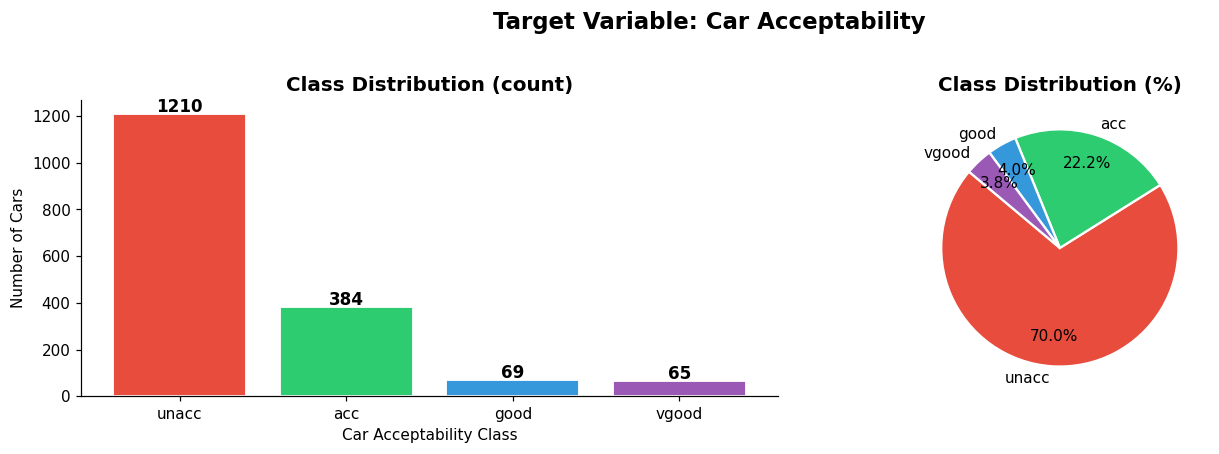

📊 Most cars are 'unacc' (unacceptable) – the dataset is imbalanced.


In [8]:
# ── Visualise class distribution ────────────────────────────────────────
# The target column shows how many cars fall into each acceptability class.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts = df['class'].value_counts()
colors = ['#e74c3c','#2ecc71','#3498db','#9b59b6']

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Car Acceptability Class')
axes[0].set_ylabel('Number of Cars')
for i, (val) in enumerate(class_counts.values):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Car Acceptability', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print("📊 Most cars are 'unacc' (unacceptable) – the dataset is imbalanced.")

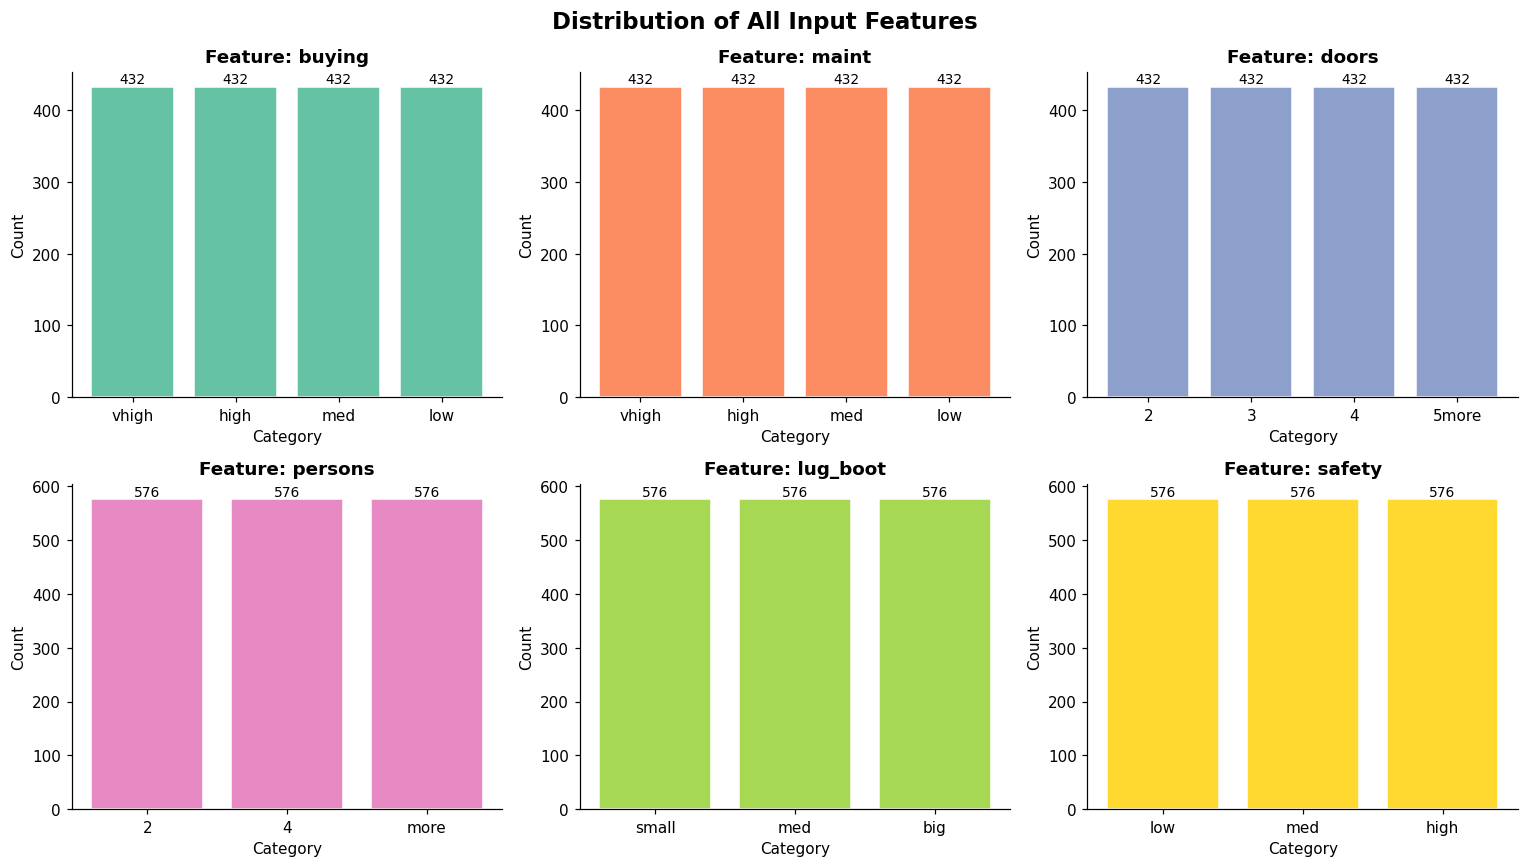

In [9]:
# ── Feature distributions ───────────────────────────────────────────────
# We plot the count of each category per feature to understand the data spread.
feature_cols = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

palette = sns.color_palette("Set2", 6)

for i, col in enumerate(feature_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=palette[i], edgecolor='white', linewidth=1)
    axes[i].set_title(f'Feature: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9)

plt.suptitle('Distribution of All Input Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Declare Features & Target <a id='4'></a>
- **X** → all 6 input columns (what the model learns from)  
- **y** → the `class` column (what we want to predict)

In [10]:
X = df.drop('class', axis=1)   # feature matrix
y = df['class']                # target vector

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y:  {y.shape}")
print(f"\nClasses to predict: {y.unique()}")

Feature matrix X: (1728, 6)
Target vector y:  (1728,)

Classes to predict: ['unacc' 'acc' 'vgood' 'good']


## 5. Train / Test Split <a id='5'></a>
We hold out **33 %** of the data as a test set so we can evaluate the model on examples it has never seen during training.  
`random_state=42` ensures the split is reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)
print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")

Training set : 1157 rows
Test set     : 571 rows


## 6. Feature Engineering – Ordinal Encoding <a id='6'></a>
Decision trees in scikit-learn require **numeric** input.  
All our columns are categorical text (e.g. `"vhigh"`, `"low"`), so we use **OrdinalEncoder** to convert each category to an integer.  
We *fit* the encoder on the training data and then *transform* both train and test sets to prevent data leakage.

In [12]:
encoder = ce.OrdinalEncoder(cols=feature_cols)

# Fit on train ONLY, then transform both sets
X_train = encoder.fit_transform(X_train)
X_test  = encoder.transform(X_test)

print("Training set after encoding:")
print(X_train.head())

Training set after encoding:
      buying  maint  doors  persons  lug_boot  safety
48         1      1      1        1         1       1
468        2      1      1        2         2       1
155        1      2      1        1         2       2
1721       3      3      2        1         2       2
1208       4      3      3        1         2       2


## 7. Model 1 – Decision Tree (Gini Index) <a id='7'></a>
The **Gini Index** measures how often a randomly chosen element would be incorrectly classified.  
A Gini value of **0** means a node is perfectly pure (all samples belong to one class).

We limit `max_depth=3` so the tree is shallow and easy to visualise.

In [13]:
# ── Train ───────────────────────────────────────────────────────────────
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
clf_gini.fit(X_train, y_train)
print("✅ Gini model trained")

✅ Gini model trained


In [14]:
# ── Predict & accuracy ──────────────────────────────────────────────────
y_pred_gini       = clf_gini.predict(X_test)
y_pred_train_gini = clf_gini.predict(X_train)

acc_train_gini = accuracy_score(y_train, y_pred_train_gini)
acc_test_gini  = accuracy_score(y_test,  y_pred_gini)

print(f"Gini  –  Training accuracy : {acc_train_gini:.4f}")
print(f"Gini  –  Test     accuracy : {acc_test_gini:.4f}")
if abs(acc_train_gini - acc_test_gini) < 0.05:
    print("\n✅ Train and test scores are close → no significant overfitting.")

Gini  –  Training accuracy : 0.7865
Gini  –  Test     accuracy : 0.8021

✅ Train and test scores are close → no significant overfitting.


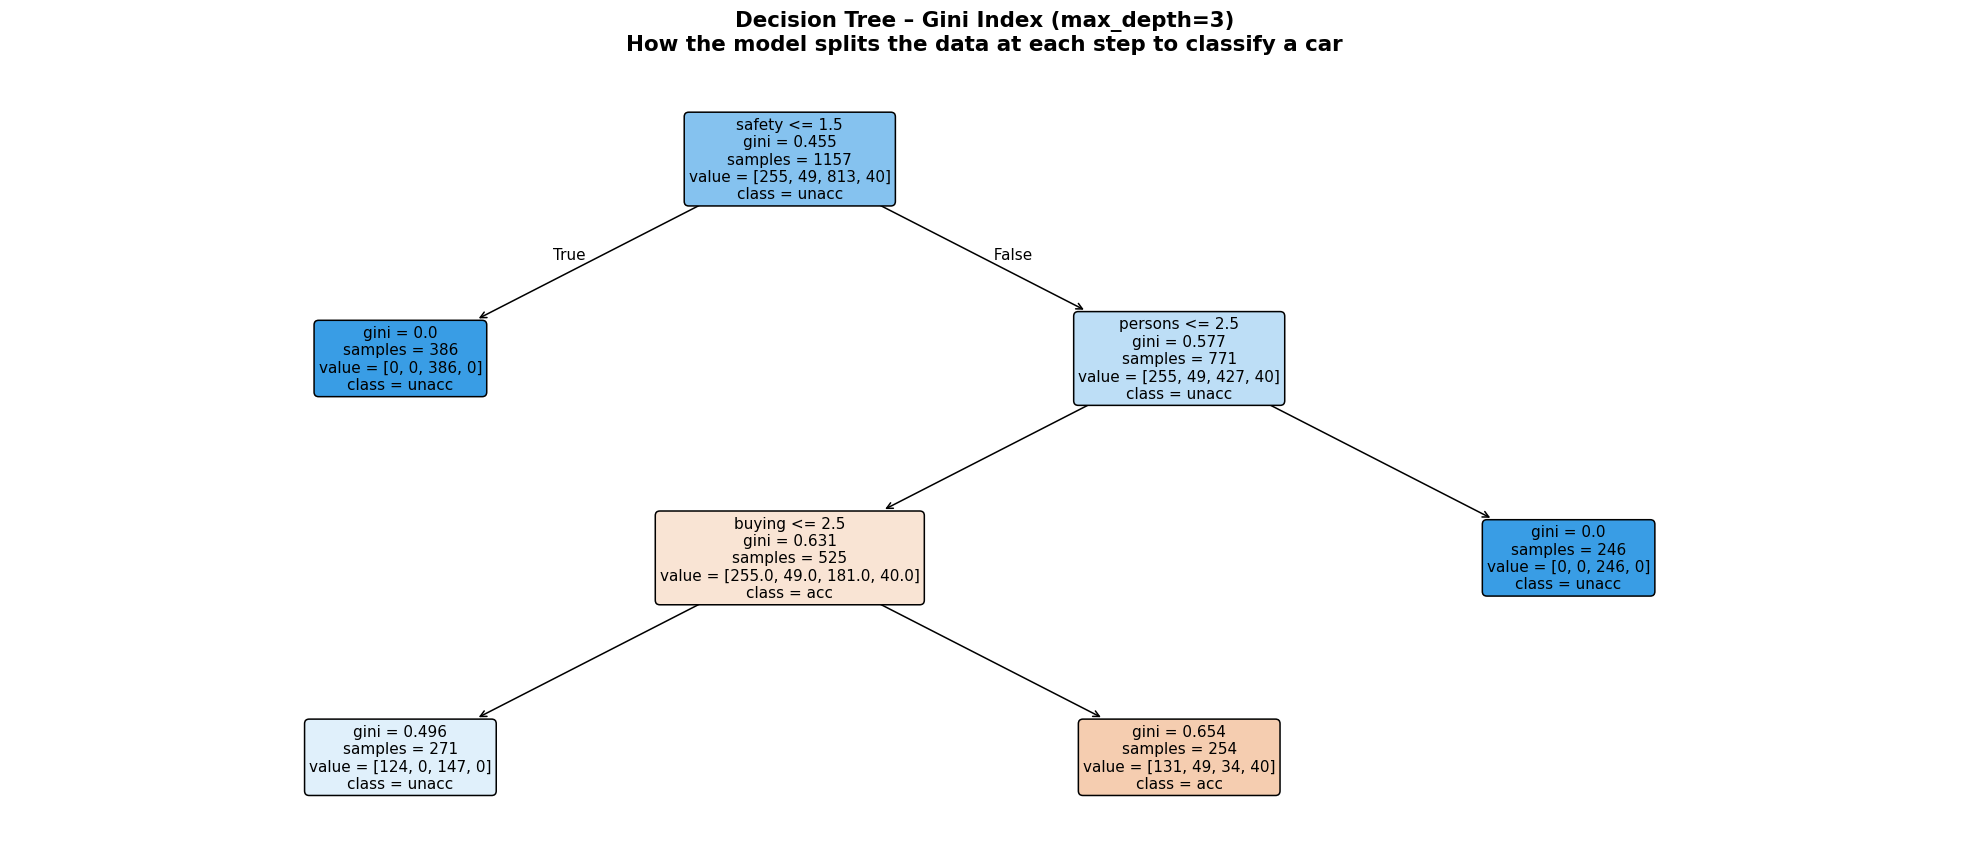


📖 Reading the tree:
  • Each box = a decision node or leaf
  • Top line  = the splitting rule (e.g. safety <= 1.5)
  • gini      = impurity of that node (0 = pure, higher = mixed)
  • samples   = how many training rows reach this node
  • value     = count per class [acc, good, unacc, vgood]
  • class     = majority class at this node
  • Colour    = the dominant class (intensity = purity)


In [15]:
# ── Visualise the Gini Decision Tree ────────────────────────────────────
# Each node shows: the splitting rule, gini value, sample count, class counts
# Leaf nodes show the final predicted class (most common class in that node)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    clf_gini,
    feature_names=X_train.columns.tolist(),
    class_names=clf_gini.classes_,
    filled=True,          # colour nodes by class
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title(
    'Decision Tree – Gini Index (max_depth=3)\n'
    'How the model splits the data at each step to classify a car',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tree_gini.png', bbox_inches='tight')
plt.show()
print("\n📖 Reading the tree:")
print("  • Each box = a decision node or leaf")
print("  • Top line  = the splitting rule (e.g. safety <= 1.5)")
print("  • gini      = impurity of that node (0 = pure, higher = mixed)")
print("  • samples   = how many training rows reach this node")
print("  • value     = count per class [acc, good, unacc, vgood]")
print("  • class     = majority class at this node")
print("  • Colour    = the dominant class (intensity = purity)")

## 8. Model 2 – Decision Tree (Entropy / Information Gain) <a id='8'></a>
**Entropy** measures the disorder or randomness in the data.  
The algorithm picks the split that gives the greatest **information gain** (= largest drop in entropy).  
Entropy = 0 → pure node. Entropy = 1 → maximally mixed (for binary problems).

In [16]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
clf_en.fit(X_train, y_train)
print("✅ Entropy model trained")

✅ Entropy model trained


In [17]:
y_pred_en       = clf_en.predict(X_test)
y_pred_train_en = clf_en.predict(X_train)

acc_train_en = accuracy_score(y_train, y_pred_train_en)
acc_test_en  = accuracy_score(y_test,  y_pred_en)

print(f"Entropy  –  Training accuracy : {acc_train_en:.4f}")
print(f"Entropy  –  Test     accuracy : {acc_test_en:.4f}")

Entropy  –  Training accuracy : 0.7865
Entropy  –  Test     accuracy : 0.8021


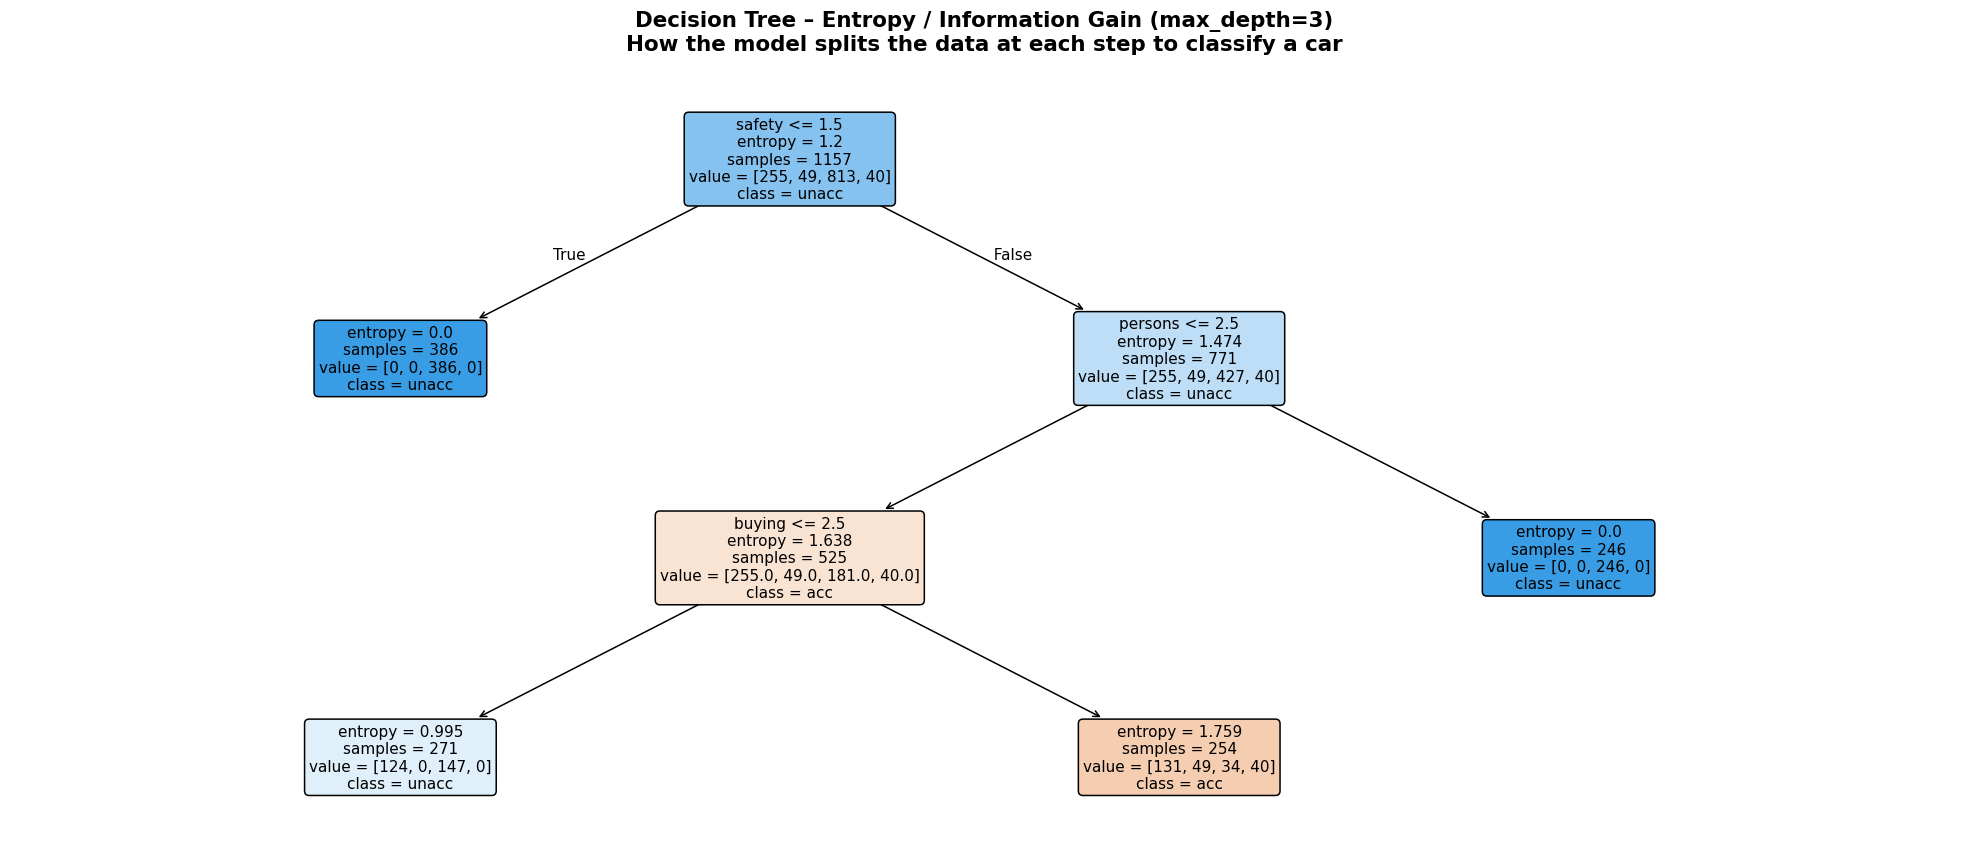

In [18]:
# ── Visualise the Entropy Decision Tree ─────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    clf_en,
    feature_names=X_train.columns.tolist(),
    class_names=clf_en.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title(
    'Decision Tree – Entropy / Information Gain (max_depth=3)\n'
    'How the model splits the data at each step to classify a car',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tree_entropy.png', bbox_inches='tight')
plt.show()

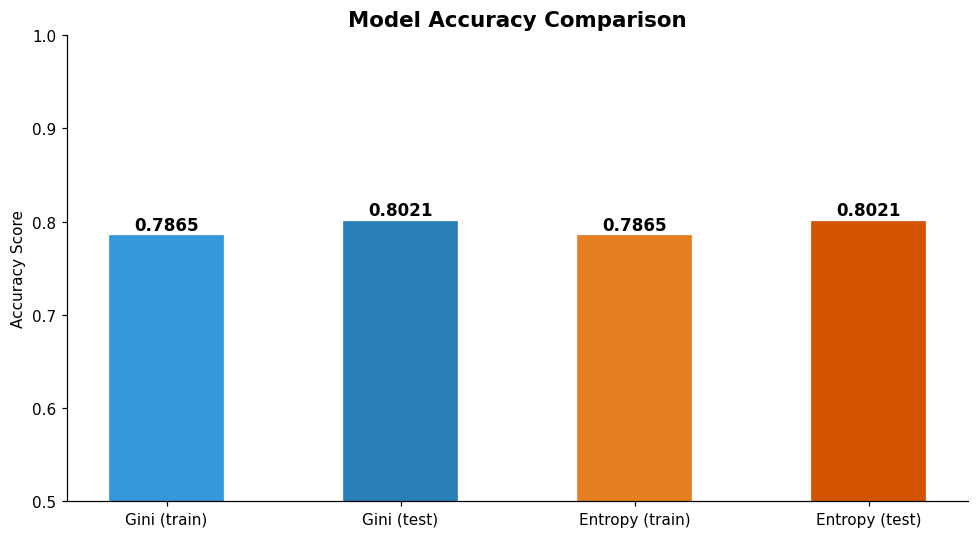

In [19]:
# ── Side-by-side accuracy comparison ────────────────────────────────────
models   = ['Gini (train)', 'Gini (test)', 'Entropy (train)', 'Entropy (test)']
scores   = [acc_train_gini, acc_test_gini, acc_train_en, acc_test_en]
bar_cols = ['#3498db','#2980b9','#e67e22','#d35400']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, scores, color=bar_cols, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy Score')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, sc in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{sc:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 9. Confusion Matrix <a id='9'></a>
A **confusion matrix** shows the counts of:
- **True Positives** – correctly predicted per class  
- **False Positives** – predicted as a class but actually something else  
- **False Negatives** – actually that class but predicted differently  

We show the matrix for the Entropy model (both models give identical results here).

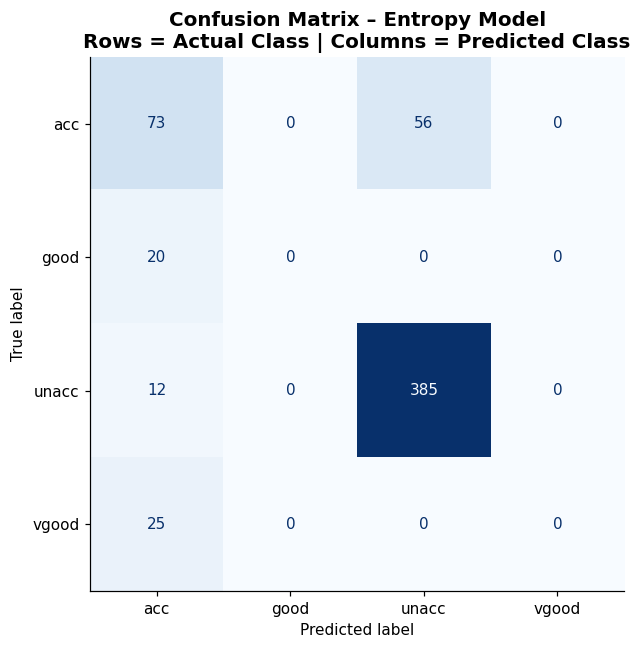


📖 How to read:
  • Diagonal cells (dark blue) = CORRECT predictions
  • Off-diagonal cells         = ERRORS (misclassifications)
  • The model handles 'unacc' very well (large number on diagonal)
  • 'good' and 'vgood' have fewer samples → harder to predict


In [20]:
cm = confusion_matrix(y_test, y_pred_en, labels=clf_en.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_en.classes_)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(
    'Confusion Matrix – Entropy Model\n'
    'Rows = Actual Class | Columns = Predicted Class',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

print("\n📖 How to read:")
print("  • Diagonal cells (dark blue) = CORRECT predictions")
print("  • Off-diagonal cells         = ERRORS (misclassifications)")
print("  • The model handles 'unacc' very well (large number on diagonal)")
print("  • 'good' and 'vgood' have fewer samples → harder to predict")

## 10. Classification Report <a id='10'></a>
- **Precision** – of all cars predicted as class X, how many really are X?  
- **Recall**    – of all cars that really are class X, how many did we catch?  
- **F1-score**  – harmonic mean of precision and recall (balanced measure)  
- **Support**   – actual number of test samples in that class

=== Classification Report (Entropy Model) ===

              precision    recall  f1-score   support

         acc       0.56      0.57      0.56       129
        good       0.00      0.00      0.00        20
       unacc       0.87      0.97      0.92       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.80       571
   macro avg       0.36      0.38      0.37       571
weighted avg       0.73      0.80      0.77       571



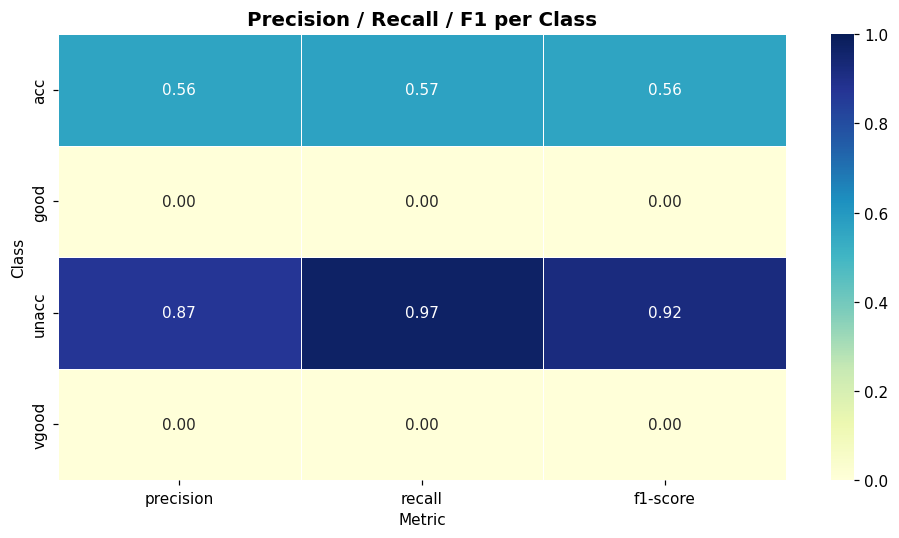

In [21]:
report = classification_report(y_test, y_pred_en, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)

print("=== Classification Report (Entropy Model) ===\n")
print(classification_report(y_test, y_pred_en))

# ── Heatmap of the report ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
# Only the class rows, not the averages
class_rows = list(clf_en.classes_)
plot_data  = report_df.loc[class_rows, ['precision','recall','f1-score']]
sns.heatmap(plot_data.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=ax, vmin=0, vmax=1)
ax.set_title('Precision / Recall / F1 per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Class')
plt.tight_layout()
plt.savefig('classification_report_heatmap.png', bbox_inches='tight')
plt.show()

## 11. Results & Conclusion <a id='11'></a>

| Model | Train Accuracy | Test Accuracy |
|-------|:--------------:|:-------------:|
| Gini Index | 0.7865 | 0.8021 |
| Entropy    | 0.7865 | 0.8021 |

**Key takeaways:**
1. Both criteria produce identical trees at `max_depth=3` for this dataset.  
2. Train (~0.79) and test (~0.80) scores are very close → **no overfitting**.  
3. The model classifies **`unacc`** cars very accurately (precision 0.87, recall 0.97) because they make up 70 % of the data.  
4. **`good`** and **`vgood`** classes have very few samples, so the model struggles with them – a classic **class imbalance** problem.  
5. The first split in *both* trees is on **`safety`** – the most informative feature. A low safety score instantly makes a car unacceptable.  

**What we learnt:**
- Decision Trees are intuitive and easy to visualise.
- The *criterion* (Gini vs Entropy) rarely changes the result much in practice.
- Limiting `max_depth` prevents overfitting but may underfit complex patterns.
- For imbalanced datasets, consider techniques like SMOTE or class weighting.
